# Extended Data Fig. 19c,d - Effect of volumetric correction on detecting neuronal decrease

**ED19c.** Recall of App-NL-G-F-specific neuronal-decrease regions when density is computed from raw anatomical volume instead of atlas-corrected volume, with the standard (atlas-registered) pipeline set as Recall = 1.0. Using raw volumes the recall drops to 0.394 (= intersection / atlas-corrected set).

**ED19d.** Representative validation in the claustrum (CLA): raw regional volume shows a significant decrease, density from raw volume is non-significant, whereas density from atlas-corrected volume reveals a significant neuronal decrease.

Pipeline: raw-space volume -> raw-volume regional density -> per-region negative-binomial GLM -> recall of raw vs corrected significant sets (ED19c) -> CLA three-panel comparison (ED19d).

> CLA is selected explicitly (Allen CCFv3 id 583); other "missed" regions are not shown. Figures preserved from the original run (the CLA panel is the claustrum case); Japanese stripped; verbose logs removed.

## Input files

| File | Content |
|---|---|
| per-sample `img_density.tif` + ANTs transforms | raw-space volume |
| `Regional_cellome4.csv` / `Regional_cellome4_raw_volume.csv` | corrected / raw-volume regional density |
| `WT_9m_vs_APP_9m_raw_value_regions_{,using_raw_volume_}NeuN_decrease.csv` | GLM significant-region sets (for recall) |
| `GOvsID_6region_removed.csv`, `summary_CUBIC-Atlas-1-1.csv` | region color / acronym |

Samples: WT 9m (Ctr9m, n=4), App 9m (n=4).

## 1. Raw regional volume (native space) and raw-volume regional density

In [ ]:
import tifffile
from scipy import ndimage # scipy.ndimage 
import numpy as np

#
start_time = datetime.datetime.now()
print("Start time:", start_time)
#Samples = ["#5_APPmodel_Ctr9m_1_2023_0130_1607", ]#"#5_APPmodel_Ctr9m_2_2023_0216_2052" ,"#5_APPmodel_Ctr9m_3_2023_0322_2014","#5_APPmodel_Ctr9m_4_2023_0518_1449","#5_APPmodel_APP9m_1_2023_0117_1352","#5_APPmodel_APP9m_2_2023_0327_1425", "#5_APPmodel_APP9m_3_2023_0329_1611", "#5_APPmodel_APP9m_4_2023_0403_1443" ]
Samples = ["#4_APPmodel_APP1m_1_2022_1102_1304", "#5_APPmodel_APP3m_4_2023_0214_2027","#4_APPmodel_APP5m_4_2023_0509_1021","#5_APPmodel_APP7m_5_2023_0520_1723"  ]
for Sample in Samples:
    param_path = "/home/mitani/CUBIC-informatics/param/Neuronomics/" + Sample + "/param_multichannel-rank.json"

    #print(param_path)

    #try:

    with open(param_path) as f:
        param = json.load(f)

    fw_dir_nu = param["dst_basedir"]
    #######################################
    if ("Neurology_project_data_archive" not in fw_dir_nu and
        not re.search(r'/ds1_Imaging[23]/', fw_dir_nu)):

        fw_dir_nu = re.sub(
            r'^(/data\d+/)',                  # /dataX/  
            r'\1Neurology_project_data_archive/',
            fw_dir_nu
        )
    ##########################################
    print(fw_dir_nu )
    
    fw_dir_nu_img_density = fw_dir_nu.replace("intensities_", "scalemerged_/img_density.tif")
    img_density = tifffile.imread(fw_dir_nu_img_density)
    print(img_density.shape)
    
    img_density[img_density>0] =1
    img_density[img_density<=0] =0
    img_density = ndimage.binary_fill_holes(img_density)
    tifffile.imsave(fw_dir_nu_img_density.replace("img_density", "img_density_binary_closed"), img_density.astype(np.uint16))
    #
    non_zero_coords = np.argwhere(img_density)
    non_zero_values = img_density[non_zero_coords[:, 0], non_zero_coords[:, 1], non_zero_coords[:, 2]]

    #
    df_non_zero = pd.DataFrame(non_zero_coords, columns=['z', 'y', 'x'])
    df_non_zero['id'] = non_zero_values   
    
    #
    df_save = df_non_zero.copy()
    #df.columns = ['X(um)', 'Y(um)', 'Z(um)', 'atlasID']
    #df
    df_save.columns = ['X(um)', 'Y(um)', 'Z(um)', 'atlasID'] # raw xyz 
    df_save["X(um)"] = df_non_zero ["x"] #* 50  # 50um scale 
    df_save["Y(um)"] = df_non_zero ["y"] #* 50
    df_save["Z(um)"] = df_non_zero ["z"] #* 50
    df_save["atlasID"] = df_non_zero ["id"]     
    #df_save.to_csv(fw_dir_nu + "50um_grid_on_raw_space.csv.gz", index=False, compression='gzip')
    
    df_save4 = df_save#pd.read_csv(fw_dir_nu + "50um_grid_on_raw_space.csv.gz", compression='gzip')
    
    #
    
    if 1==1:
        print("IN")

        #
        z_step = 1 / 3 # 16.7um #5 #  10um 
        y_step = 1 / 3 #5
        x_step = 1 / 3 #5

        #
        y_indices = np.arange(0, img_density.shape[1], y_step)
        x_indices = np.arange(0, img_density.shape[2], x_step)

        #
        y_vals = np.repeat(y_indices, len(x_indices))
        x_vals = np.tile(x_indices, len(y_indices))
        z_vals = np.zeros(len(x_vals))  #  z 0

        #
        single_z_grid_df = pd.DataFrame({
            'z': z_vals,
            'y': y_vals,
            'x': x_vals
        })

        del z_vals,y_vals,x_vals
        gc.collect()

        #
        first_block_z_values = np.arange(0, img_density.shape[0] / 5, z_step)
        first_block_z_values = np.round(first_block_z_values, 3)

        #
        first_block_dfs = []
        for z in first_block_z_values:
            print(z)
            temp_df = single_z_grid_df.copy()
            temp_df['z'] = z
            first_block_dfs.append(temp_df)
        del temp_df, single_z_grid_df
        gc.collect()

        #
        first_block_df = pd.concat(first_block_dfs, ignore_index=True)
        del first_block_dfs
        gc.collect()

        #
        grid_points_df = pd.DataFrame(columns=['z', 'y', 'x'])

        tree = cKDTree(df_save4[['X(um)', 'Y(um)', 'Z(um)']].values)

        #
        for i in range(5):
            print(i)
            temp_df = first_block_df.copy()
            #
            temp_df['z'] += i * (img_density.shape[0] / 5)
            #

            distances, indexes = tree.query(temp_df[['x', 'y', 'z']].values, k=1, distance_upper_bound = 2, n_jobs = -1)
            mask = distances <= 2 ** 0.5


            grid_points_df = pd.concat([grid_points_df, temp_df[mask]], ignore_index=True)

            print(str((len(temp_df[mask])/len(temp_df)) * 100) + "%")

            del temp_df, mask, distances, indexes
            gc.collect()

        #
        del first_block_df
        gc.collect()

        #
        print("Grid generation completed.")
        
        grid_points_df2 = grid_points_df.copy()
        grid_points_df2[['z', 'y', 'x']] = grid_points_df[['z', 'y', 'x']] * 50 # um scale
        
        #
        if 1==1:
            df_transformed = ants.apply_transforms_to_points(
            dim=3,
            points=grid_points_df2,
            transformlist=[os.path.join(fw_dir_nu.replace("intensities_", "nu_R_/result"), "F2M_0GenericAffine.mat"),
                        os.path.join(fw_dir_nu.replace("intensities_", "nu_R_/result"), "F2M_InvWarped.nii.gz")],
            whichtoinvert = [True, False]
            )
                                
        df_transformed[['z', 'y', 'x']] = df_transformed[['z', 'y', 'x']] * 1/50 # 50um scale
        if 1==1:
            transformed_points = ants.apply_transforms_to_points(
                dim=3,
                points=df_transformed,
                transformlist=["/data4/Neurology_project_data_archive/atlas_R_test/slice_0_88_inv.mat"],
                whichtoinvert = [True]
            )

            print("trasform end")

        #del   grid_points_df
        #gc.collect()




    transformed_points = pd.DataFrame({'id': range(len(transformed_points)), 'x': transformed_points["x"], 'y': transformed_points["y"], 'z': transformed_points["z"]})

                                                         
    dt_stitched = np.dtype([
        ('z', 'f4'), ('y', 'f4'), ('x', 'f4'),
    ])

    data_annotated =  np.zeros((grid_points_df.shape[0],), dtype=dt_stitched)
    data_annotated["x"]  = grid_points_df["x"] # 50um scale
    data_annotated["y"]  = grid_points_df["y"]
    data_annotated["z"]  = grid_points_df["z"]
    data_annotated.tofile(fw_dir_nu + "Raw-space-grid-16.7um-resolution_ver1.bin")
    print(data_annotated)                                                 
                                                         
    #
    if 1==1:
        scale = 1/50

        depth_ori = img_density.shape[0]
        height_ori = img_density.shape[1]
        width_ori = img_density.shape[2]

        print(depth_ori)
        print(height_ori)
        print(width_ori)

        img_filename_Nuclear_Isocortex_to_ori = fw_dir_nu + "Raw_16.7um_grid_points_50um.tif"

        img_N_ori,_ = np.histogramdd(
            np.vstack([
                data_annotated["z"],
                data_annotated["y"], 
                data_annotated["x"] 
                ]).T,
                bins=(depth_ori, height_ori, width_ori),
                range=[(0,depth_ori),(0,height_ori),(0,width_ori)] ##########################    ！！！！！
            )

        tifffile.imsave(
                img_filename_Nuclear_Isocortex_to_ori,
                img_N_ori.astype(np.float32)
            )
        del img_N_ori
        gc.collect()   
                                                         
    #
    if 1==1:
        df_list = []
        df_list = [grid_points_df.iloc[offset::6] for offset in range(6)]
        dt_stitched = np.dtype([
            ('z', 'f4'), ('y', 'f4'), ('x', 'f4')
        ])

        for i in [0, 1,2, 3, 4, 5]:
            data_annotated =  np.zeros((len(df_list[i]),), dtype=dt_stitched)
            data_annotated["x"]  = df_list[i]["x"] # 50um scale
            data_annotated["y"]  = df_list[i]["y"]
            data_annotated["z"]  = df_list[i]["z"]
            #data_annotated["id"]  = df_list[i]["id"]
            data_annotated.tofile(fw_dir_nu + "Raw-space-grid-16.7um-resolution_ver1_" +str(i)+".bin")   
                                                        
    dt_stitched = np.dtype([
        ('z', 'f4'), ('y', 'f4'), ('x', 'f4'),
    ])

    data_annotated =  np.zeros((df_transformed.shape[0],), dtype=dt_stitched)
    data_annotated["x"]  = df_transformed["x"] # 50um scale
    data_annotated["y"]  = df_transformed["y"]
    data_annotated["z"]  = df_transformed["z"]
    data_annotated.tofile(fw_dir_nu + "CUBIC-space-grid-16.7um-resolution_ver1.bin")
    print(data_annotated)                                                      
                                                         
    #
    if 1==1:
        scale = 1/50

        depth_ori = 243#img_density.shape[0]
        height_ori = 440#img_density.shape[1]
        width_ori = 339#img_density.shape[2]

        print(depth_ori)
        print(height_ori)
        print(width_ori)

        img_filename_Nuclear_Isocortex_to_ori = fw_dir_nu + "CUBIC-space_16.7um_grid_points_50um.tif"

        img_N_ori,_ = np.histogramdd(
            np.vstack([
                data_annotated["z"],# 50um scale
                data_annotated["y"], 
                data_annotated["x"] 
                ]).T,
                bins=(depth_ori, height_ori, width_ori),
                range=[(0,depth_ori),(0,height_ori),(0,width_ori)] ##########################    ！！！！！
            )

        tifffile.imsave(
                img_filename_Nuclear_Isocortex_to_ori,
                img_N_ori.astype(np.float32)
            )
        del img_N_ori
        gc.collect()  
                                                         
    #
    if 1==1:
        df_list = []
        df_list = [df_transformed.iloc[offset::6] for offset in range(6)]
        dt_stitched = np.dtype([
            ('z', 'f4'), ('y', 'f4'), ('x', 'f4')
        ])

        for i in [0, 1,2, 3, 4, 5]:
            data_annotated =  np.zeros((len(df_list[i]),), dtype=dt_stitched)
            data_annotated["x"]  = df_list[i]["x"]# 50um scale
            data_annotated["y"]  = df_list[i]["y"]
            data_annotated["z"]  = df_list[i]["z"]
            #data_annotated["id"]  = df_list[i]["id"]
            data_annotated.tofile(fw_dir_nu + "CUBIC-space-grid-16.7um-resolution_ver1_" +str(i)+".bin") 
                                                         
    
    dt_stitched_corrected = np.dtype([
        ('z', 'f4'), ('y', 'f4'), ('x', 'f4'), ('id', 'u4')  # 'u4' np.uint32 
    ])

    data_annotated =  np.zeros((transformed_points.shape[0],), dtype=dt_stitched_corrected)
    data_annotated["x"]  = transformed_points["x"]# 50um scale
    data_annotated["y"]  = transformed_points["y"]
    data_annotated["z"]  = transformed_points["z"]
    data_annotated["id"]  = transformed_points["id"]
    data_annotated.tofile(fw_dir_nu + "SCA-space-grid_only_Affined-16.7um-resolution_ver1.bin")
    print(data_annotated) 
                                                         
    #
    if 1==1:
        scale = 1/50

        depth_ori = 320 #243#img_density.shape[0]
        height_ori = 528 #440#img_density.shape[1]
        width_ori = 456 #339#img_density.shape[2]

        print(depth_ori)
        print(height_ori)
        print(width_ori)

        img_filename_Nuclear_Isocortex_to_ori = fw_dir_nu + "SCA-space_only_Affined_16.7um_grid_points_50um.tif"

        img_N_ori,_ = np.histogramdd(
            np.vstack([
                data_annotated["z"],# 50um scale
                data_annotated["y"], 
                data_annotated["x"] 
                ]).T,
                bins=(depth_ori, height_ori, width_ori),
                range=[(0,depth_ori),(0,height_ori),(0,width_ori)] ##########################    ！！！！！
            )

        tifffile.imsave(
                img_filename_Nuclear_Isocortex_to_ori,
                img_N_ori.astype(np.float32)
            )
        del img_N_ori
        gc.collect()                      
                                                
    #
    if 1==1:
        df_list = []
        df_list = [transformed_points.iloc[offset::6] for offset in range(6)]
        dt_stitched_corrected = np.dtype([
            ('z', 'f4'), ('y', 'f4'), ('x', 'f4'), ('id', 'u4')  # 'u4' np.uint32 
        ])

        for i in [0, 1,2, 3, 4, 5]:
            data_annotated =  np.zeros((len(df_list[i]),), dtype=dt_stitched_corrected)
            data_annotated["x"]  = df_list[i]["x"]
            data_annotated["y"]  = df_list[i]["y"]
            data_annotated["z"]  = df_list[i]["z"]
            data_annotated["id"]  = df_list[i]["id"]
            data_annotated.tofile(fw_dir_nu + "SCA-space-grid_only_Affined-16.7um-resolution_ver1_" +str(i)+".bin")

                                                         
    end_time = datetime.datetime.now()
    print("End time:", end_time)
    print("Duration:", end_time - start_time)

In [ ]:
#

dt_annotation2 = np.dtype([
  ('stitched_x', 'f4'), ('stitched_y', 'f4'), ('stitched_z', 'f4'),
  ('mapped_x', 'f4'), ('mapped_y', 'f4'), ('mapped_z', 'f4'),
  ('SCA_x', 'f4'), ('SCA_y', 'f4'), ('SCA_z', 'f4'),
  ('atlas_id', 'u2')
])

dt_simple2 = np.dtype([
    ('mapped_x', 'f4'), ('mapped_y', 'f4'), ('mapped_z', 'f4'), 
    ('NeuN_positive','f4'),('Iba1_positive','f4'),('atlas_id', 'u2')
])

dt_SCA = np.dtype([
  ('SCA_x', 'f4'), ('SCA_y', 'f4'), ('SCA_z', 'f4'),
  ('NeuN_positive','f4'),('Iba1_positive','f4'),('atlas_id', 'u2')
])

data_GO = pd.read_csv(filepath_or_buffer="/data4/ds1_Imaging3/atlas_for_fig/GOvsID_6region_removed.csv", encoding="ms932", sep=",")
#
ids = data_GO["id"].astype(int)
ids=np.array(ids)

NeuN_cluster_threshold_list = [0.80] #  0.75 
NeuN_cluster_noise_threshold_list = [0.55] #  0.75 
Iba1_cluster_threshold_list = [0.55] #  0.45 

all_paths = ["#5_APPmodel_Ctr9m_1_2023_0130_1607","#5_APPmodel_Ctr9m_2_2023_0216_2052" ,"#5_APPmodel_Ctr9m_3_2023_0322_2014","#5_APPmodel_Ctr9m_4_2023_0518_1449","#5_APPmodel_APP9m_1_2023_0117_1352","#5_APPmodel_APP9m_2_2023_0327_1425", "#5_APPmodel_APP9m_3_2023_0329_1611", "#5_APPmodel_APP9m_4_2023_0403_1443" ]

for Sample in all_paths:
    
    #
    print("\n")
    start_time = datetime.datetime.now()
    start_time2 = datetime.datetime.now()
    print("Start Start time:", start_time)
    
    param_path = "/home/mitani/CUBIC-informatics/param/Neuronomics/" + Sample + "/param_multichannel-rank.json"

    print(param_path)
  
    try:
        
        with open(param_path) as f:
            param = json.load(f)

        fw_dir_nu = param["dst_basedir"]
        #######################################
        if ("Neurology_project_data_archive" not in fw_dir_nu and
            not re.search(r'/ds1_Imaging[23]/', fw_dir_nu)):

            fw_dir_nu = re.sub(
                r'^(/data\d+/)',                  # /dataX/  
                r'\1Neurology_project_data_archive/',
                fw_dir_nu
            )
        ##########################################
        print(fw_dir_nu )
        #
        if not os.path.exists(fw_dir_nu + "/regional_cellome_done5_raw.txt"):
            #
            print("regional_cellome_done5.txt does not exist. So, start to calculate regional cellome.")
        else:
            print("regional_cellome_done5.txt is existing. So skip.")
            continue

        #
        #
        SCA_cells = pd.DataFrame() #pd.read_csv()
        for i in range(0,6):
            print(i)
            #
            temp_df = np.fromfile(fw_dir_nu + "/SCA_registered_cell_coordinates_ver2_2_"+str(i)+ ".bin", dtype=dt_annotation2)

            if SCA_cells.size == 0:
                SCA_cells = temp_df  #  
            else:
                SCA_cells = np.concatenate((SCA_cells, temp_df), axis=0)

            del temp_df
            gc.collect()
            
        SCA_data = np.zeros((len(SCA_cells),), dtype=dt_SCA)
        SCA_data["SCA_x"] = SCA_cells["SCA_x"]
        SCA_data["SCA_y"] = SCA_cells["SCA_y"]
        SCA_data["SCA_z"] = SCA_cells["SCA_z"]

        SCA_data["NeuN_positive"] = 1#Classified_cells['NeuN_positive']
        SCA_data["Iba1_positive"] = 1#Classified_cells['Iba1_positive']

        SCA_data["atlas_id"] = SCA_cells["atlas_id"]

        del SCA_cells
        gc.collect()

        SCA_data = pd.DataFrame(SCA_data)

        print(len(SCA_data))       
        
        #
        id_counts_All_cell = SCA_data["atlas_id"].value_counts()
        id_counts_NeuN = SCA_data["atlas_id"][SCA_data["NeuN_positive"] > 0].value_counts()
        id_counts_Iba1 = SCA_data["atlas_id"][SCA_data["Iba1_positive"] > 0].value_counts()
        id_counts_others = SCA_data["atlas_id"][(SCA_data["NeuN_positive"] < 1) & (SCA_data["Iba1_positive"] < 1)].value_counts()

        #
        filtered_counts_All_cell = id_counts_All_cell.reindex(ids, fill_value=0)
        filtered_counts_NeuN = id_counts_NeuN.reindex(ids, fill_value=0)
        filtered_counts_Iba1 = id_counts_Iba1.reindex(ids, fill_value=0)
        filtered_counts_others = id_counts_others.reindex(ids, fill_value=0)
        #
        df_filtered_All_cell = filtered_counts_All_cell.reset_index()
        df_filtered_All_cell.columns = ['atlasID', 'All_cell_count']  #  
        df_filtered_NeuN = filtered_counts_NeuN.reset_index()
        df_filtered_NeuN.columns = ['atlasID', 'NeuN_cell_count']  #  
        df_filtered_Iba1 = filtered_counts_Iba1.reset_index()
        df_filtered_Iba1.columns = ['atlasID', 'Iba1_cell_count']  #  
        df_filtered_others = filtered_counts_others.reset_index()
        df_filtered_others.columns = ['atlasID', 'Others_cell_count']  #  
        #df_filtered_All_cell

        #
        df_filtered_All_cell['NeuN_cell_count'] = 0
        df_filtered_All_cell['Iba1_cell_count'] = 0
        df_filtered_All_cell['Others_cell_count'] = 0
        df_filtered_All_cell["Total_volume (mm3)"] = 0
        df_filtered_All_cell["All cell density (/mm3)"] = 0
        df_filtered_All_cell["NeuN+ density (/mm3)"] = 0
        df_filtered_All_cell["Iba1+ density (/mm3)"] = 0
        df_filtered_All_cell["Others+ density (/mm3)"] = 0
        df_filtered_All_cell["NeuN+ ratio"] = 0
        df_filtered_All_cell["Iba1+ ratio"] = 0
        df_filtered_All_cell["Others+ ratio"] = 0

        df_filtered_All_cell['NeuN_cell_count'] = df_filtered_NeuN ['NeuN_cell_count']
        df_filtered_All_cell['Iba1_cell_count'] = df_filtered_Iba1 ['Iba1_cell_count']
        df_filtered_All_cell['Others_cell_count'] = df_filtered_others ['Others_cell_count']
        df_filtered_All_cell["Total_volume (mm3)"] = df_filtered_NeuN ['NeuN_cell_count'] * ((50/3) * 0.001) ** 3 # mm3 
        df_filtered_All_cell["All cell density (/mm3)"] = 1#df_filtered_All_cell  ['All_cell_count'][Volume_list_3D["iso_10um_voxel_count"] >0] / (Volume_list_3D["iso_10um_voxel_count"][Volume_list_3D["iso_10um_voxel_count"] >0] * (10 * 0.001) ** 3)
        df_filtered_All_cell["NeuN+ density (/mm3)"] = 1#df_filtered_NeuN ['NeuN_cell_count'][Volume_list_3D["iso_10um_voxel_count"] >0] / (Volume_list_3D["iso_10um_voxel_count"][Volume_list_3D["iso_10um_voxel_count"] >0] * (10 * 0.001) ** 3)
        df_filtered_All_cell["Iba1+ density (/mm3)"]= 1#df_filtered_Iba1 ['Iba1_cell_count'][Volume_list_3D["iso_10um_voxel_count"] >0] / (Volume_list_3D["iso_10um_voxel_count"][Volume_list_3D["iso_10um_voxel_count"] >0] * (10 * 0.001) ** 3)
        df_filtered_All_cell["Others+ density (/mm3)"]= 1#df_filtered_others ['Others_cell_count'][Volume_list_3D["iso_10um_voxel_count"] >0] / (Volume_list_3D["iso_10um_voxel_count"][Volume_list_3D["iso_10um_voxel_count"] >0] * (10 * 0.001) ** 3)
        df_filtered_All_cell["NeuN+ ratio"]= 1#df_filtered_NeuN ['NeuN_cell_count'][df_filtered_All_cell['All_cell_count']>0]/df_filtered_All_cell['All_cell_count'][df_filtered_All_cell['All_cell_count']>0]
        df_filtered_All_cell["Iba1+ ratio"]= 1#df_filtered_Iba1 ['Iba1_cell_count'][df_filtered_All_cell['All_cell_count']>0]/df_filtered_All_cell['All_cell_count'][df_filtered_All_cell['All_cell_count']>0]
        df_filtered_All_cell["Others+ ratio"] = 1#df_filtered_others ['Others_cell_count'][df_filtered_All_cell['All_cell_count']>0]/df_filtered_All_cell['All_cell_count'][df_filtered_All_cell['All_cell_count']>0]

        print(df_filtered_All_cell.head())

        #
        df_filtered_All_cell.to_csv(fw_dir_nu +  "/Regional_cellome4_raw_volume.csv", index=False)

        print("Regional_cellome4.csv save has done.")

        del df_filtered_All_cell, SCA_data
        gc.collect()

        print("regional_cellome_done5.txt file's save starts.")
        #
        with open(fw_dir_nu + "/regional_cellome_done5_raw.txt", 'w') as f:
            f.write("done\n")
        print("regional_cellome_done5.txt file's save has done.")
        
    except:
        print("SCA or PDFcluster file does not exist. Skip this time.")

## 2. Per-region negative-binomial GLM (raw volume)

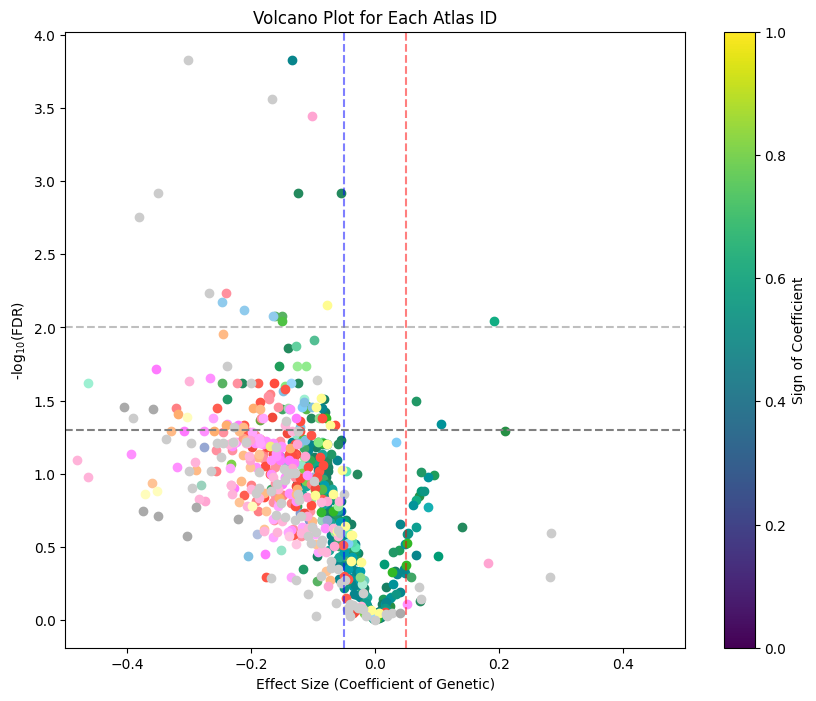

In [1]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

import numpy as np
import rpy2.robjects as robjects
import rpy2.robjects as ro
#
r = robjects.r
from rpy2.robjects import pandas2ri
pandas2ri.activate()
#
r = robjects.r
r('library(MASS)')

#
def run_glm (data):
        
    #
    ro.globalenv['data'] = pandas2ri.py2rpy(data)
    #
    r_code = '''
    library(MASS)
    model <- glm.nb('log_All_cell_count ~ Genetic', data = data)
    coef <- summary(model)$coefficients["Genetic", "Estimate"]
    p_value <- summary(model)$coefficients["Genetic", "Pr(>|z|)"]
    c(coef, p_value)
    '''
    #results_ <- summary(model)
    #results_ <- summary(model)
    #p_value <- summary(model)$Coefficients["Genetic", "Pr(>|z|)"]
    #coef <- summary(model)$Coefficients["Genetic", "coef"]
    ro.r(r_code)

    results = ro.r(r_code)
    
    coef = results[0]
    p_value = results[1]
    print(f"Coefficient: {coef}, p-value: {p_value}")
    
    return coef, p_value


#
def load_data(sample_info):
    df_list = []
    df_list2 = []
    for sample, condition in sample_info:  # sample_info (sample_path, condition) 
        param_path = f"/home/mitani/CUBIC-informatics/param/Neuronomics/{sample}/param_multichannel-rank.json"
        try:
            with open(param_path) as f:
                param = json.load(f)
            fw_dir_nu = param["dst_basedir"]
            #######################################
            if ("Neurology_project_data_archive" not in fw_dir_nu and
                not re.search(r'/ds1_Imaging[23]/', fw_dir_nu)):

                fw_dir_nu = re.sub(
                    r'^(/data\d+/)',                  # /dataX/  
                    r'\1Neurology_project_data_archive/',
                    fw_dir_nu
                )
            ##########################################
            print(fw_dir_nu )

            cellome_file = fw_dir_nu + "/Regional_cellome4.csv"
            if os.path.exists(cellome_file):  #  
                print(sample)
                df = pd.read_csv(cellome_file)
                df['Condition'] = condition  # 'Condition'  
                df['Sample'] = sample  #  
                df_list.append(df)
                
            cellome_file = fw_dir_nu + "/Regional_cellome4_raw_volume.csv"
            if os.path.exists(cellome_file):  #  
                print(sample)
                df = pd.read_csv(cellome_file)
                df['Condition'] = condition  # 'Condition'  
                df['Sample'] = sample  #  
                df_list2.append(df)
                
        except Exception as e:
            print(f"Error loading data for {sample}: {e}")

    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame(), pd.concat(df_list2, ignore_index=True) if df_list else pd.DataFrame()

#
healthy_sample_info = [(s, c) for c in ["WT_9m"] for s in conditions[c]]
disease_sample_info = [(s, c) for c in [ "APP_9m"] for s in conditions[c]]
#healthy_sample_info = [(s, c) for c in ["WT_7m", "WT_9m"] for s in conditions[c]]
#disease_sample_info = [(s, c) for c in [  "APP_7m", "APP_9m"] for s in conditions[c]]

#
healthy_data,healthy_data_raw_vol = load_data(healthy_sample_info)
disease_data, disease_data_raw_vol = load_data(disease_sample_info)

#
#healthy_data['Age'] = healthy_data['Condition'].str.extract('(\d+)m').astype(int)
healthy_data['Genetic'] = 0  # Healthy 0
healthy_data_raw_vol['Genetic'] = 0  # Healthy 0
#disease_data['Age'] = disease_data['Condition'].str.extract('(\d+)m').astype(int)
disease_data['Genetic'] = 1  # Disease 1
disease_data_raw_vol['Genetic'] = 1  # Disease 1

#
all_data = pd.concat([healthy_data, disease_data], ignore_index=True)
all_data2 = pd.concat([healthy_data_raw_vol, disease_data_raw_vol], ignore_index=True)
all_data['log_All_cell_count'] = 0

#
#mean_age = all_data['Age'].mean()
#print(mean_age)
#all_data["Age"] = all_data["Age"] - mean_age

#
results = {}
for atlas_id in all_data['atlasID'].unique():
    print(atlas_id)
    data = all_data[all_data['atlasID'] == atlas_id]
    data2 = all_data2[all_data2['atlasID'] == atlas_id]

    #
    #
    #
    
    numerator = data['NeuN_cell_count']
    denominator = data2['Total_volume (mm3)']
    
    #
    #
    denominator_safe = denominator.replace(0, np.nan)
    
    #
    #
    data['log_All_cell_count'] = np.round(numerator / denominator_safe)
    
    #
    data = data.dropna(subset=['log_All_cell_count'])
    
    all_data.loc[data.index, 'log_All_cell_count'] = data['log_All_cell_count']
    
    if data['log_All_cell_count'].sum() <= 0.0:
        results[atlas_id] = [0.0, 1.0]
        print(f"No non-zero data available for atlas ID {atlas_id}. Skipping...")
        continue
    results[atlas_id] = run_glm(data)

volcano_data = pd.DataFrame({
    'AtlasID': list(results.keys()),
    'coef': [result[0] for result in results.values()],
    'pvalue': [result[1] for result in results.values()]

})

#
volcano_data['pvalue'][volcano_data['pvalue'] == 0.0] = 1.0
_, p_adjusted, _, _ = multipletests(volcano_data['pvalue'], method='fdr_bh')

#
volcano_data['adjusted_pvalue'] =  p_adjusted
volcano_data['-log10(adjusted_pvalue)'] = -np.log10(volcano_data['adjusted_pvalue'])

#
volcano_data = pd.merge(volcano_data, data_GO[['id', 'R', 'G', 'B']], left_on='AtlasID', right_on='id', how='left')

#
volcano_data['color'] = volcano_data.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)

#volcano_data['log2(coef)'] = np.log2(volcano_data['coef'])

###########################

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10  # Adjust the size as needed

#
plt.figure(figsize=(10, 8))
for _, row in volcano_data.iterrows():
    plt.scatter(row['coef'], row['-log10(adjusted_pvalue)'], color=row['color'])

plt.xlabel("Effect Size (Coefficient of Genetic)")
plt.ylabel(r'-$\log_{10}$(FDR)')  # LaTeX 
plt.title('Volcano Plot for Each Atlas ID')
plt.xlim(-0.5,0.5)
#plt.ylim(-0.5,10)
plt.axvline(x=-0.05, color='blue', linestyle='--', alpha = 0.5)
plt.axvline(x=0.05, color='red', linestyle='--', alpha = 0.5)
plt.axhline(y=-np.log10(0.05), color='grey', linestyle='--', alpha = 1.0)
plt.axhline(y=-np.log10(0.01), color='grey', linestyle='--', alpha = 0.5)
plt.colorbar(label='Sign of Coefficient')
plt.show()

## 3. Recall of neuronal-decrease regions: raw vs atlas-corrected volume (Extended Data Fig. 19c)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re # re  

def load_atlas_ids(path):
    """
    CSV 'atlasID' ID 
     
    """
    if not os.path.exists(path):
        print(f"Warning: File not found, skipping: {path}")
        return set()
    try:
        df = pd.read_csv(path)
        if 'atlasID' not in df.columns:
            print(f"Warning: 'atlasID' column not found in {path}. Returning empty set.")
            return set()
        return set(df['atlasID'].unique())
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return set()

def calculate_recall(base_set, raw_set):
    """
    Recall = (Intersection) / (Base Set Count)
    Recall ( ): base_set   raw_set  
    """
    #
    if len(base_set) == 0:
        return 0.0, 0, len(raw_set), 0 #  
    
    intersection_count = len(base_set.intersection(raw_set))
    recall = intersection_count / len(base_set)
    
    return recall, len(base_set), len(raw_set), intersection_count

#
#
base_path = "/data4/Neurology_project_data_archive/Region/"

#
categories = ['NeuN_decrease', 'Iba1_increase', 'Iba1_decrease']

#
file_paths = {
    'NeuN_decrease': {
        'base': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_NeuN_decrease.csv'),
        'raw': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_using_raw_volume_NeuN_decrease.csv')
    },
    'Iba1_increase': {
        'base': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_Iba1_increase.csv'),
        'raw': os.path.join(base_path,'WT_9m_vs_APP_9m_raw_value_regions_using_raw_volume_Iba1_increase.csv')
    },
    'Iba1_decrease': {
        'base': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_Iba1_decrease.csv'),
        'raw': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_using_raw_volume_Iba1_decrease.csv')
    }
}

#
results = []
for category in categories:
    print(f"Processing category: {category}")
    
    #
    base_ids = load_atlas_ids(file_paths[category]['base'])
    raw_ids = load_atlas_ids(file_paths[category]['raw'])
    
    #
    recall, base_count, raw_count, intersection = calculate_recall(base_ids, raw_ids)
    
    results.append({
        'Category': category,
        'Recall': recall,
        'Base_Count (N)': base_count, # ( )
        'Raw_Volume_Count (N)': raw_count, # ( )
        'Intersection (N)': intersection # ( )
    })

#
recall_df = pd.DataFrame(results)

print("\n--- Calculation Results ---")
print(recall_df)

#
recall_df.to_csv("recall_comparison_results.csv", index=False)
print("\nResults saved to recall_comparison_results.csv")

#
print("Generating bar plot...")
#
try:
    plt.rcParams['font.family'] = 'Arial' # 'DejaVu Sans'   'Hiragino Sans'  
except RuntimeError:
    print("Arial font not found, using default.")
    
plt.figure(figsize=(10, 7))

#
colors = {
    'NeuN_decrease': '#0072B2', # Blue
    'Iba1_increase': '#D55E00', # Red/Orange
    'Iba1_decrease': '#009E73'  # Green
}
bar_colors = recall_df['Category'].map(colors).fillna('grey')

bars = plt.bar(recall_df['Category'], recall_df['Recall'], color=bar_colors, alpha=0.8, width=0.6)

#
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=12, color='black')

plt.xlabel("Category of Change", fontsize=14)
plt.ylabel("Recall (Normalized by 'Base' Count)", fontsize=14)
plt.title("Recall of 'Raw Volume' Method vs 'Base' Method", fontsize=16, pad=20)
plt.ylim(0, 1.1) # Y  0   1.1 (100% +  )  
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

#
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

#
output_filename = "recall_comparison_barplot.png"
plt.savefig(output_filename, dpi=300)

print(f"Bar plot saved to {output_filename}")
plt.show()

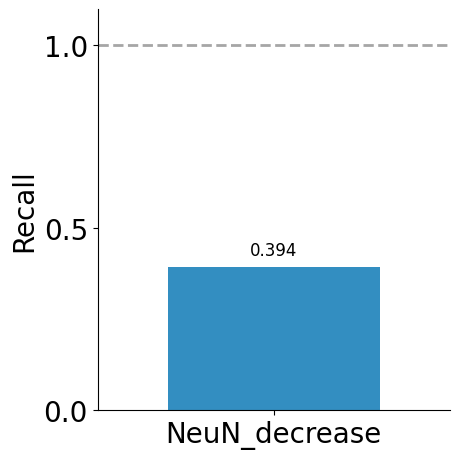

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re # re  
import matplotlib
matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.size'] = 20

def load_atlas_ids(path):
    """
    CSV 'atlasID' ID 
     
    """
    if not os.path.exists(path):
        print(f"Warning: File not found, skipping: {path}")
        return set()
    try:
        df = pd.read_csv(path)
        if 'atlasID' not in df.columns:
            print(f"Warning: 'atlasID' column not found in {path}. Returning empty set.")
            return set()
        return set(df['atlasID'].unique())
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return set()

def calculate_recall(base_set, raw_set):
    """
    Recall = (Intersection) / (Base Set Count)
    Recall ( ): base_set   raw_set  
    """
    #
    if len(base_set) == 0:
        return 0.0, 0, len(raw_set), 0 #  
    
    intersection_count = len(base_set.intersection(raw_set))
    recall = intersection_count / len(base_set)
    
    return recall, len(base_set), len(raw_set), intersection_count

#
#
base_path = "/data4/Neurology_project_data_archive/Region/"

#
categories = ['NeuN_decrease', ]#'Iba1_increase', 'Iba1_decrease']

#
file_paths = {
    'NeuN_decrease': {
        'base': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_NeuN_decrease.csv'),
        'raw': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_using_raw_volume_NeuN_decrease.csv')
    },
    #'Iba1_increase': {
    #    'base': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_Iba1_increase.csv'),
    #    'raw': os.path.join(base_path,'WT_9m_vs_APP_9m_raw_value_regions_using_raw_volume_Iba1_increase.csv')
    #},
    #'Iba1_decrease': {
    #    'base': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_Iba1_decrease.csv'),
    #    'raw': os.path.join(base_path, 'WT_9m_vs_APP_9m_raw_value_regions_using_raw_volume_Iba1_decrease.csv')
    #}
}

#
results = []
for category in categories:
    print(f"Processing category: {category}")
    
    #
    base_ids = load_atlas_ids(file_paths[category]['base'])
    raw_ids = load_atlas_ids(file_paths[category]['raw'])
    
    #
    recall, base_count, raw_count, intersection = calculate_recall(base_ids, raw_ids)
    
    results.append({
        'Category': category,
        'Recall': recall,
        'Base_Count (N)': base_count, # ( )
        'Raw_Volume_Count (N)': raw_count, # ( )
        'Intersection (N)': intersection # ( )
    })

#
recall_df = pd.DataFrame(results)

print("\n--- Calculation Results ---")
print(recall_df)

#
recall_df.to_csv("recall_comparison_results.csv", index=False)
print("\nResults saved to recall_comparison_results.csv")

#
print("Generating bar plot...")
#
try:
    plt.rcParams['font.family'] = 'Arial' # 'DejaVu Sans'   'Hiragino Sans'  
except RuntimeError:
    print("Arial font not found, using default.")
    
plt.figure(figsize=(5, 5))

#
colors = {
    'NeuN_decrease': '#0072B2', # Blue
    #'Iba1_increase': '#D55E00', # Red/Orange
    #'Iba1_decrease': '#009E73'  # Green
}
bar_colors = recall_df['Category'].map(colors).fillna('grey')

bars = plt.bar(recall_df['Category'], recall_df['Recall'], color=bar_colors, alpha=0.8, width=0.6)

#
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=12, color='black')

#plt.xlabel("Category of Change", fontsize=14)
plt.ylabel("Recall", )
#plt.title("Recall of 'Raw Volume' Method vs 'Base' Method",  pad=20)
plt.xlim(-0.5, 0.5) # Y  0   1.1 (100% +  )  
plt.ylim(0, 1.1) # Y  0   1.1 (100% +  )  
#plt.xticks(fontsize=12)
plt.yticks([0.0,0.5,1.0])
plt.axhline(y=1.0, color='gray', alpha = 0.7,linestyle='--', linewidth=2)

#
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

#
plt.savefig('/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/APP9m_WT9_mNeuron_decrease_recall_using_raw_volume_barplot.pdf', 
        transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)

print(f"Bar plot saved to {output_filename}")
plt.show()

## 4. Claustrum (CLA) three-panel comparison (Extended Data Fig. 19d)

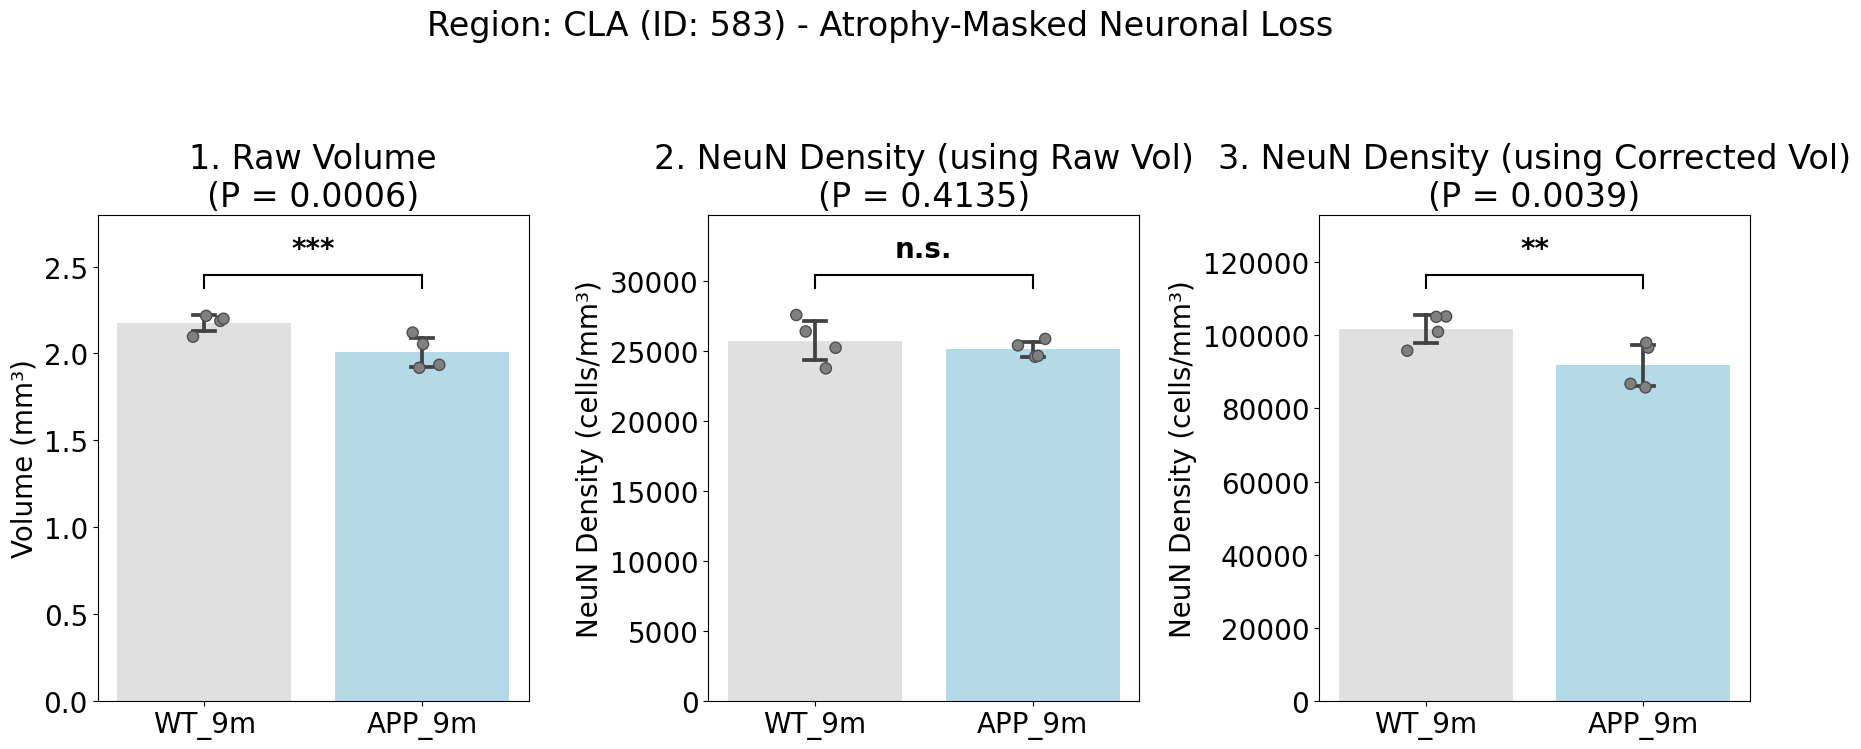

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import sys
from statsmodels.stats.multitest import multipletests
matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.size'] = 20
#
try:
    import rpy2.robjects as robjects
    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    pandas2ri.activate()
    r = robjects.r
    r('library(MASS)')
except ImportError:
    print(" : rpy2   R 'MASS' ")
    print("pip install rpy2")
    sys.exit()

#
def run_glm(data):
    """
    R glm.nb 
    """
    try:
        ro.globalenv['data'] = pandas2ri.py2rpy(data)
        r_code = '''
        library(MASS)
        model <- glm.nb(log_All_cell_count ~ Genetic, data = data)
        coef <- summary(model)$coefficients["Genetic", "Estimate"]
        p_value <- summary(model)$coefficients["Genetic", "Pr(>|z|)"]
        c(coef, p_value)
        '''
        results = ro.r(r_code)
        coef = results[0]
        p_value = results[1]
        print(f"Coefficient: {coef:.4f}, p-value: {p_value:.4f}")
        return coef, p_value
    except Exception as e:
        print(f"R glm.nb : {e}")
        print("  [0.0, 1.0]  ")
        return 0.0, 1.0

#
def load_data(sample_info):
    df_list = []
    df_list2 = []
    for sample, condition in sample_info:
        param_path = f"/home/mitani/CUBIC-informatics/param/Neuronomics/{sample}/param_multichannel-rank.json"
        try:
            with open(param_path) as f:
                param = json.load(f)
            fw_dir_nu = param["dst_basedir"]
            
            #
            if ("Neurology_project_data_archive" not in fw_dir_nu and
                not re.search(r'/ds1_Imaging[23]/', fw_dir_nu)):
                fw_dir_nu = re.sub(
                    r'^(/data\d+/)',
                    r'\1Neurology_project_data_archive/',
                    fw_dir_nu
                )
            
            # File 1: Corrected Volume Data (Regional_cellome4.csv)
            cellome_file = fw_dir_nu + "/Regional_cellome4.csv"
            if os.path.exists(cellome_file):
                print(f"Loading (Corrected): {sample}")
                df = pd.read_csv(cellome_file)
                df['Condition'] = condition
                df['Sample'] = sample
                df_list.append(df)
            
            # File 2: Raw Volume Data (Regional_cellome4_raw_volume.csv)
            cellome_file_raw = fw_dir_nu + "/Regional_cellome4_raw_volume.csv"
            if os.path.exists(cellome_file_raw):
                print(f"Loading (Raw Vol): {sample}")
                df_raw = pd.read_csv(cellome_file_raw)
                df_raw['Condition'] = condition
                df_raw['Sample'] = sample
                df_list2.append(df_raw)
                
        except Exception as e:
            print(f"Error loading data for {sample}: {e}")

    all_data = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()
    all_data_raw_vol = pd.concat(df_list2, ignore_index=True) if df_list2 else pd.DataFrame()
    
    return all_data, all_data_raw_vol

#
def run_statistical_analysis(all_data, analysis_type="Volume", all_data_raw=None):
    """
     3 GLM 
    """
    print(f"\n---  : {analysis_type} ---")
    results = {}
    
    #
    data_for_glm = all_data.copy()
    
    if analysis_type == "Volume":
        #
        if all_data_raw is None:
             raise ValueError("Volume  all_data_raw  ")
        #
        data_for_glm = pd.merge(
            all_data[['Sample', 'atlasID', 'Genetic']],
            all_data_raw[['Sample', 'atlasID', 'Total_volume (mm3)']],
            on=['Sample', 'atlasID'],
            how='left'
        )
        data_for_glm['log_All_cell_count'] = np.round(data_for_glm['Total_volume (mm3)'] * 1000000) # (  /mm3   /um3  ?)
    
    elif analysis_type == "NeuN_Corrected":
        #
        data_for_glm['log_All_cell_count'] = np.round(data_for_glm['NeuN+ density (/mm3)'])
    
    elif analysis_type == "NeuN_Raw":
        #
        if all_data_raw is None:
             raise ValueError("NeuN_Raw  all_data_raw  ")
        #
        data_for_glm = pd.merge(
            all_data[['Sample', 'atlasID', 'Genetic', 'NeuN_cell_count']],
            all_data_raw[['Sample', 'atlasID', 'Total_volume (mm3)']],
            on=['Sample', 'atlasID'],
            how='left'
        )
        numerator = data_for_glm['NeuN_cell_count']
        denominator_safe = data_for_glm['Total_volume (mm3)'].replace(0, np.nan)
        data_for_glm['log_All_cell_count'] = np.round(numerator / denominator_safe)
    
    else:
        raise ValueError("  analysis_type  ")

    #
    for atlas_id in data_for_glm['atlasID'].unique():
        print(f"Processing {analysis_type}: {atlas_id}")
        data_region = data_for_glm[data_for_glm['atlasID'] == atlas_id].copy()
        
        #
        data_region = data_region.dropna(subset=['log_All_cell_count', 'Genetic'])
        
        #
        if data_region.empty or data_region['log_All_cell_count'].sum() <= 0.0 or len(data_region['Genetic'].unique()) < 2:
            results[atlas_id] = [0.0, 1.0]
            print(f"  Skipping {atlas_id} ( )")
            continue
            
        results[atlas_id] = run_glm(data_region)

    #
    volcano_data = pd.DataFrame({
        'AtlasID': list(results.keys()),
        'coef': [result[0] for result in results.values()],
        'pvalue': [result[1] for result in results.values()]
    })

    #
    volcano_data['pvalue'] = volcano_data['pvalue'].fillna(1.0).replace(0.0, 1.0)
    _, p_adjusted, _, _ = multipletests(volcano_data['pvalue'], method='fdr_bh')
    volcano_data['adjusted_pvalue'] = p_adjusted
    
    print(f"--- {analysis_type}   ---")
    return volcano_data

#

def pvalue_to_stars(p):
    """FDR (adjusted_pvalue)  """
    if p >= 0.05:
        return 'n.s.'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return ''

def add_significance_bar(ax, fdr_value):
    """ """
    y_max = ax.get_ylim()[1]
    bar_y = y_max * 1.05
    text_y = y_max * 1.08
    
    ax.plot([0, 1], [bar_y, bar_y], color='black', linewidth=1.5)
    ax.plot([0, 0], [y_max * 1.02, bar_y], color='black', linewidth=1.5)
    ax.plot([1, 1], [y_max * 1.02, bar_y], color='black', linewidth=1.5)
    
    ax.text(0.5, text_y, pvalue_to_stars(fdr_value), ha='center', va='bottom',  fontweight='bold')
    ax.set_ylim(top=y_max * 1.2)

# =================================================================
#
# =================================================================

#
#
# conditions = {
#     "WT_9m": ["sample_A", "sample_B", ...],
#     "APP_9m": ["sample_C", "sample_D", ...]
# }
#
# ▲▲▲ 

#
print("---  1:   ---")
healthy_sample_info = [(s, "WT_9m") for s in conditions["WT_9m"]]
disease_sample_info = [(s, "APP_9m") for s in conditions["APP_9m"]]
healthy_data, healthy_data_raw_vol = load_data(healthy_sample_info)
disease_data, disease_data_raw_vol = load_data(disease_sample_info)

healthy_data['Genetic'] = 0
healthy_data_raw_vol['Genetic'] = 0
disease_data['Genetic'] = 1
disease_data_raw_vol['Genetic'] = 1

all_data = pd.concat([healthy_data, disease_data], ignore_index=True)
all_data_raw = pd.concat([healthy_data_raw_vol, disease_data_raw_vol], ignore_index=True)

#
# 1. Volume
volcano_data_vol = run_statistical_analysis(
    all_data, 
    analysis_type="Volume", 
    all_data_raw=all_data_raw
)
# 2. NeuN Corrected Density
volcano_data_norm = run_statistical_analysis(
    all_data, 
    analysis_type="NeuN_Corrected"
)
# 3. NeuN Raw Density
volcano_data_raw = run_statistical_analysis(
    all_data, 
    analysis_type="NeuN_Raw", 
    all_data_raw=all_data_raw
)

#
print("\n---  2:   ---")
FDR_LIMIT = 0.05

#
atrophied_ids = set(volcano_data_vol[
    (volcano_data_vol["adjusted_pvalue"] < FDR_LIMIT) &
    (volcano_data_vol["coef"] < 0)
]["AtlasID"])

#
real_decrease_ids = set(volcano_data_norm[
    (volcano_data_norm["adjusted_pvalue"] < FDR_LIMIT) &
    (volcano_data_norm["coef"] < 0)
]["AtlasID"])

#
missed_decrease_ids = set(volcano_data_raw[
    (volcano_data_raw["adjusted_pvalue"] >= FDR_LIMIT)
]["AtlasID"])

#
target_regions = atrophied_ids.intersection(real_decrease_ids).intersection(missed_decrease_ids)

if not target_regions:
    print(" ")
    sys.exit()

print(f"---   {len(target_regions)}   ---")
print(sorted(list(target_regions)))
print("\n---  3:   ---")

#
try:
    #
    plot_data_vol = all_data_raw[['atlasID', 'Sample', 'Genetic', 'Total_volume (mm3)']]
    plot_data_norm = all_data[['atlasID', 'Sample', 'Genetic', 'NeuN+ density (/mm3)']]
    
    #
    plot_data_raw_calc = pd.merge(
        all_data[['atlasID', 'Sample', 'Genetic', 'NeuN_cell_count']],
        all_data_raw[['atlasID', 'Sample', 'Genetic', 'Total_volume (mm3)']], # 'Genetic'  
        on=['atlasID', 'Sample', 'Genetic'], # 3 
        how='left'
    )
    #
    
    plot_data_raw_calc['NeuN_Density_Raw'] = (
        plot_data_raw_calc['NeuN_cell_count'] / 
        plot_data_raw_calc['Total_volume (mm3)'].replace(0, np.nan)
    )

    #
    df_plot = pd.merge(
        plot_data_vol, 
        plot_data_norm, 
        on=['atlasID', 'Sample', 'Genetic'], 
        how='left'
    )
    df_plot = pd.merge(
        df_plot, 
        plot_data_raw_calc[['atlasID', 'Sample', 'Genetic', 'NeuN_Density_Raw']],
        on=['atlasID', 'Sample', 'Genetic'], 
        how='left'
    )

    #
    df_plot['Group'] = df_plot['Genetic'].map({0: 'WT_9m', 1: 'APP_9m'})

except KeyError as e:
    print(f" :  : {e}")
    print("all_data   all_data_raw  ")
    sys.exit()


#
print(f"---  4: {len(target_regions)}   ---")
OUTPUT_DIR = "/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
palette = {'WT_9m': 'lightgray', 'APP_9m': 'skyblue'}
plt.rcParams['font.family'] = 'Arial' #  
plt.rcParams['font.size'] = 20        #  

#

for region_id in [583]:  # CLA only (Allen CCFv3 id 583)
    print(f"Plotting Region: {region_id}")
    
    region_data = df_plot[df_plot['atlasID'] == region_id]
    if region_data.empty:
        print(f"   : region {region_id}  ")
        continue

    try:
        fdr_vol = volcano_data_vol.loc[volcano_data_vol["AtlasID"] == region_id, "pvalue"].values[0]
        fdr_raw_dens = volcano_data_raw.loc[volcano_data_raw["AtlasID"] == region_id, "pvalue"].values[0]
        fdr_norm_dens = volcano_data_norm.loc[volcano_data_norm["AtlasID"] == region_id, "pvalue"].values[0]
    except IndexError:
        print(f"   : region {region_id}  FDR ")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    
    try:
        region_acronym = data_id.loc[data_id['id'] == region_id, 'acronym'].values[0] 
        fig.suptitle(f"Region: {region_acronym} (ID: {region_id}) - Atrophy-Masked Neuronal Loss")
    except Exception as e:
        print(f" (acronym : {e})")
        fig.suptitle(f"Region: {region_id} - Atrophy-Masked Neuronal Loss")

    # --- Plot 1: Raw Volume ---
    ax1 = axes[0]
    sns.barplot(
        data=region_data, x='Group', y='Total_volume (mm3)', 
        palette=palette, ax=ax1, 
        ci='sd', capsize=0.1, order=['WT_9m', 'APP_9m'],
        alpha=0.7 #  
    )
    sns.stripplot(
        data=region_data, x='Group', y='Total_volume (mm3)',
        ax=ax1, order=['WT_9m', 'APP_9m'],
        color='gray', 
        #edgecolor='gray', 
        linewidth=1,
        size=8
    )
    ax1.set_title(f"1. Raw Volume\n(P = {fdr_vol:.4f})")
    ax1.set_xlabel("")
    ax1.set_ylabel("Volume (mm³)")
    if not region_data['Total_volume (mm3)'].isnull().all():
        add_significance_bar(ax1, fdr_vol) 

    # --- Plot 2: NeuN Density (Raw Volume) ---
    ax2 = axes[1]
    sns.barplot(
        data=region_data, x='Group', y='NeuN_Density_Raw', 
        palette=palette, ax=ax2, 
        ci='sd', capsize=0.1, order=['WT_9m', 'APP_9m'],
        alpha=0.7
    )
    sns.stripplot(
        data=region_data, x='Group', y='NeuN_Density_Raw',
        ax=ax2, order=['WT_9m', 'APP_9m'],
        color='gray', 
        #edgecolor='gray', 
        linewidth=1,
        size=8
    )
    ax2.set_title(f"2. NeuN Density (using Raw Vol)\n(P = {fdr_raw_dens:.4f})")
    ax2.set_xlabel("")
    ax2.set_ylabel("NeuN Density (cells/mm³)")
    if not region_data['NeuN_Density_Raw'].isnull().all():
        add_significance_bar(ax2, fdr_raw_dens) 

    # --- Plot 3: NeuN Density (Corrected Volume) ---
    ax3 = axes[2]
    sns.barplot(
        data=region_data, x='Group', y='NeuN+ density (/mm3)', 
        palette=palette, ax=ax3, 
        ci='sd', capsize=0.1, order=['WT_9m', 'APP_9m'],
        alpha=0.7
    )
    sns.stripplot(
        data=region_data, x='Group', y='NeuN+ density (/mm3)',
        ax=ax3, order=['WT_9m', 'APP_9m'],
        color='gray', 
        #edgecolor='gray', 
        linewidth=1,
        size=8
    )
    ax3.set_title(f"3. NeuN Density (using Corrected Vol)\n(P = {fdr_norm_dens:.4f})")
    ax3.set_xlabel("")
    ax3.set_ylabel("NeuN Density (cells/mm³)")
    if not region_data['NeuN+ density (/mm3)'].isnull().all():
        add_significance_bar(ax3, fdr_norm_dens)

    #
    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
    
    try:
        save_path = os.path.join(OUTPUT_DIR, f"Region_{region_id}_{region_acronym}_Comparison.pdf")
    except:
        save_path = os.path.join(OUTPUT_DIR, f"Region_{region_id}_Comparison.pdf")
        
    plt.savefig(save_path)
    plt.show() # (Jupyter show() )
    plt.close(fig)

print(f"\n---   ---")
print(f"  {OUTPUT_DIR}  ")